# 05_ML_Model_Comparison_Dispersion
Comprehensive ML workflow: SVR, ANN, Random Forest, Gradient Boosting

In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  

c:\Users\Public\workspace\sh-wave-ml-surrogate\classical_ml


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import models
from ml.models import get_svr, get_ann, get_rf, get_gbr


## Load / Prepare Data
Replace this with your actual dataset

In [3]:
import os
import pandas as pd
from joblib import load

ROOT = os.path.abspath("..")

# Load model and data with basic checks
data_path = os.path.join(ROOT, 'data', 'raw', 'dispersion_full_dataset.xlsx')

if not os.path.exists(data_path):
    raise FileNotFoundError(f'Data file not found: {data_path}')

data = pd.read_excel(data_path)

# Inputs
X = data[["kL", "L", "alpha1", "s", "P1", "P2"]].values

# Output (IMPORTANT)
if 'c_beta' not in data.columns:
    raise KeyError("Column 'c_beta' not found in data")
y = data["c_beta"].values

print(f"Data shape: {X.shape}")

Data shape: (31047, 6)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Initialize Models

In [5]:
models = {
    "SVR": get_svr(),
    "ANN": get_ann(),
    "Random Forest": get_rf(),
    "Gradient Boosting": get_gbr()
}


## Train and Evaluate

In [6]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

df_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
df_results


Training SVR...
Training ANN...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2
0,SVR,0.005816,0.006589,0.996457
1,ANN,0.006517,0.008651,0.993892
2,Random Forest,0.000207,0.000312,0.999992
3,Gradient Boosting,0.004157,0.005540,0.997494


## Hyperparameter Tuning (GridSearch)

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'svr__C': [10, 100],
    'svr__gamma': ['scale', 0.1],
    'svr__epsilon': [0.01, 0.1]
}

grid_svr = GridSearchCV(get_svr(), param_grid_svr, cv=3, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

print("Best SVR Params:", grid_svr.best_params_)
best_svr = grid_svr.best_estimator_


Best SVR Params: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.1}


## Dispersion Curve Plot (Actual vs Predicted)

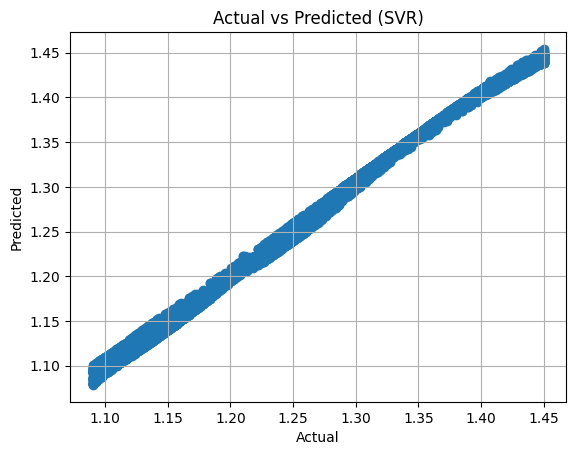

In [8]:
import matplotlib.pyplot as plt

plt.figure()

y_pred_best = best_svr.predict(X_test)

plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (SVR)")
plt.grid()

plt.show()


## Model Comparison Graph

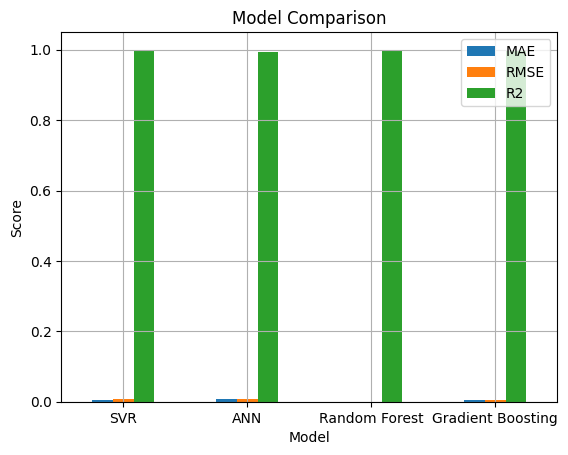

In [9]:
df_results.set_index("Model")[["MAE", "RMSE", "R2"]].plot(kind="bar")

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()

plt.show()


## Overfitting / Underfitting Analysis

In [10]:
# models = {
#     "SVR": get_svr(),
#     "ANN": get_ann(),
#     "Random Forest": get_rf(),
#     "Gradient Boosting": get_gbr()
# }


In [11]:
from sklearn.model_selection import learning_curve

import matplotlib.pyplot as plt

model = "ANN"  # you can change model here

In [12]:
# def plot_learning_curves(models, X, y):
#     from sklearn.model_selection import learning_curve
#     import matplotlib.pyplot as plt
#     import numpy as np

#     for name, model in models.items():
#         train_sizes, train_scores, test_scores = learning_curve(
#             model, X, y,
#             cv=5,
#             scoring='r2',
#             n_jobs=-1,
#             train_sizes=np.linspace(0.1, 1.0, 5)
#         )

#         train_mean = train_scores.mean(axis=1)
#         test_mean = test_scores.mean(axis=1)

#         plt.figure()
#         plt.plot(train_sizes, train_mean, label="Train Score")
#         plt.plot(train_sizes, test_mean, label="Validation Score")

#         plt.title(f"Learning Curve ({name})")
#         plt.xlabel("Training Size")
#         plt.ylabel("R2 Score")
#         plt.legend()
#         plt.grid()

#         plt.show()

In [13]:
# plot_learning_curves(models, X, y)


## Residual Analysis

In [14]:
# def plot_residuals(models, X_train, X_test, y_train, y_test):
#     import matplotlib.pyplot as plt

#     for name, model in models.items():
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         residuals = y_test - y_pred

#         plt.figure()
#         plt.scatter(y_pred, residuals)

#         plt.axhline(0)  # reference line
#         plt.title(f"Residual Plot ({name})")
#         plt.xlabel("Predicted")
#         plt.ylabel("Residuals")
#         plt.grid()

#         plt.show()

In [15]:
# plot_residuals(models, X_train, X_test, y_train, y_test)

## Model Explainability

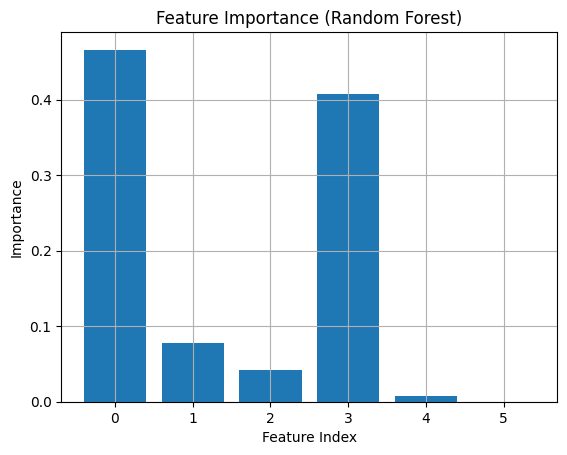

In [16]:
# For tree-based models (RF / GBR)
importances = models["Random Forest"].feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.grid()
plt.show()


### Optional: SHAP Explainability (if installed)

In [17]:
# Uncomment if SHAP is installed
# import shap
# explainer = shap.Explainer(models["Random Forest"], X_train)
# shap_values = explainer(X_test[:100])
# shap.plots.beeswarm(shap_values)


In [18]:
def plot_error_analysis(models, X_train, X_test, y_train, y_test, feature_index=0):
    import matplotlib.pyplot as plt
    import numpy as np

    for name, model in models.items():
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Residuals
        residuals = y_test - y_pred

        # 🔹 1. Histogram of residuals
        plt.figure()
        plt.hist(residuals, bins=30)
        plt.title(f"Residual Histogram ({name})")
        plt.xlabel("Residual")
        plt.ylabel("Frequency")
        plt.grid()
        plt.show()

        # 🔹 2. Residual vs input (kL) 
        kL = X_test[:, feature_index]

        plt.figure()
        plt.scatter(kL, residuals)
        plt.axhline(0)

        plt.title(f"Residual vs kL ({name})")
        plt.xlabel("kL")
        plt.ylabel("Residual")
        plt.grid()
        plt.show()

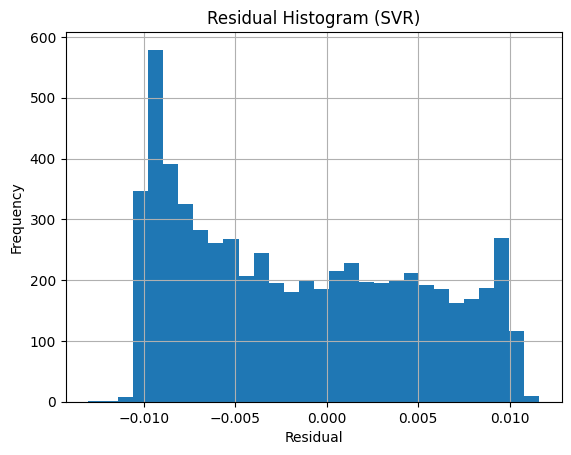

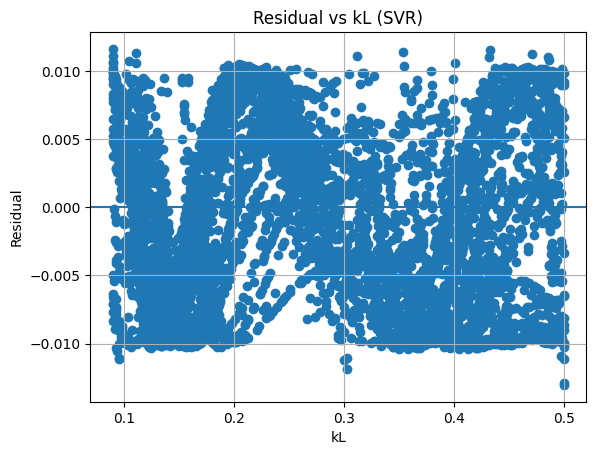

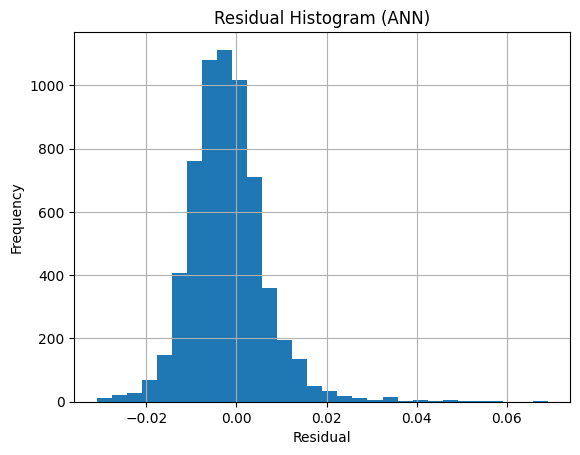

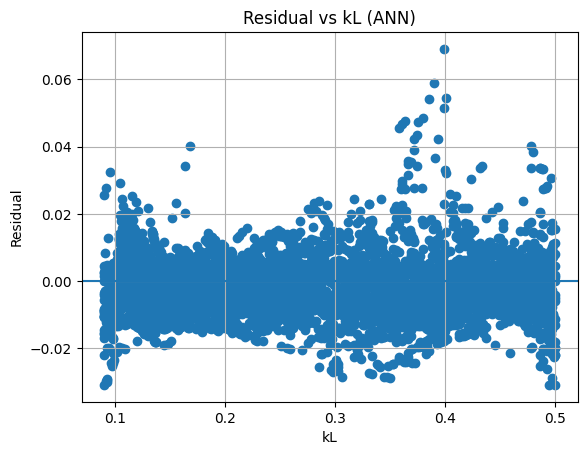

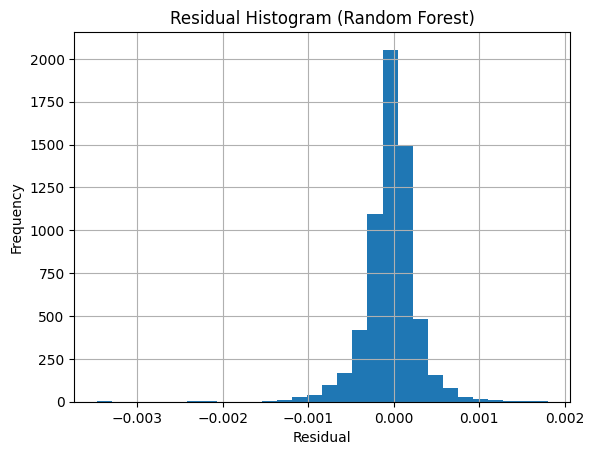

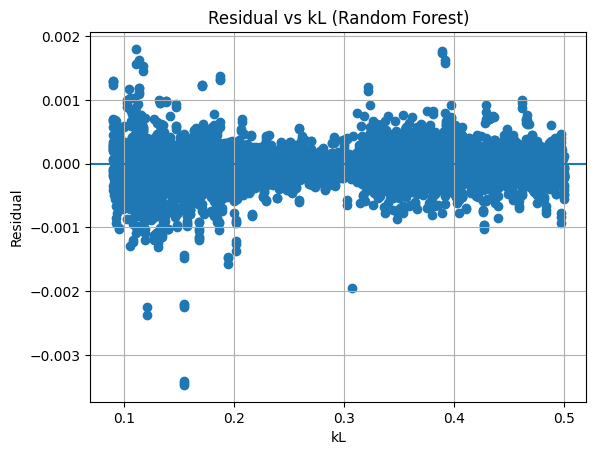

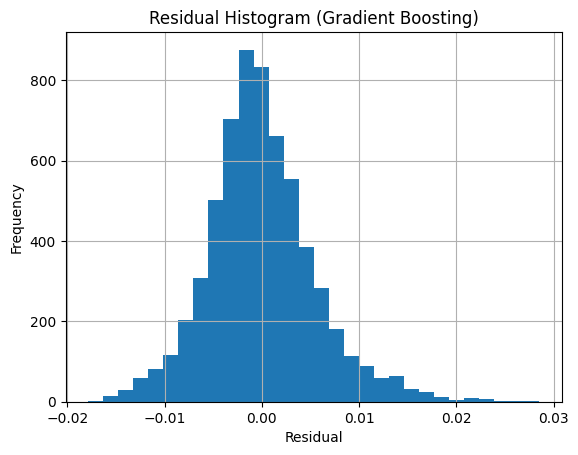

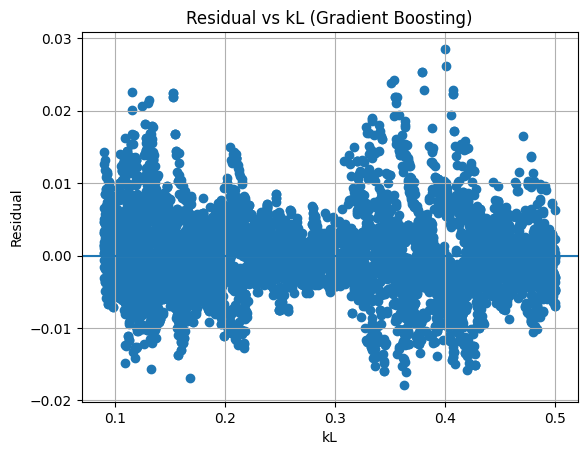

In [19]:
plot_error_analysis(models, X_train, X_test, y_train, y_test)

In [20]:
def plot_feature_importance(models, X_train, y_train, feature_names):
    import matplotlib.pyplot as plt
    
    for name, model in models.items():
        if name in ["Random Forest", "Gradient Boosting"]:
            model.fit(X_train, y_train)
            importances = model.feature_importances_

            plt.figure()
            plt.bar(feature_names, importances)
            plt.title(f"Feature Importance ({name})")
            plt.ylabel("Importance")
            plt.grid()
            plt.show()

In [21]:
def plot_permutation_importance(models, X_test, y_test, feature_names):
    from sklearn.inspection import permutation_importance
    import matplotlib.pyplot as plt

    for name, model in models.items():
        model.fit(X_train, y_train)

        result = permutation_importance(
            model, X_test, y_test,
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )

        plt.figure()
        plt.bar(feature_names, result.importances_mean)
        plt.title(f"Permutation Importance ({name})")
        plt.ylabel("Importance")
        plt.grid()
        plt.show()

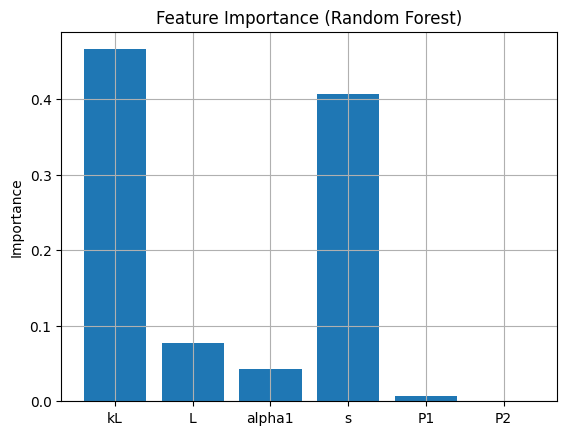

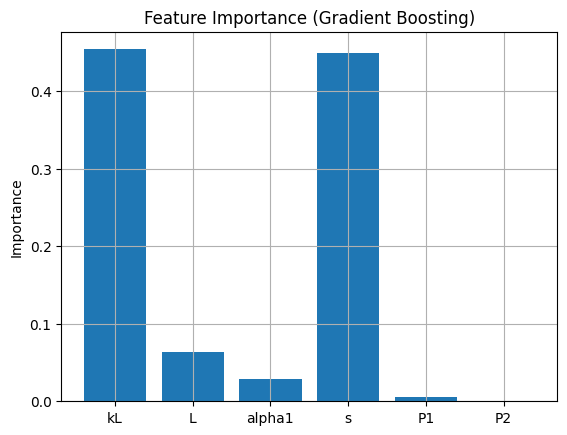

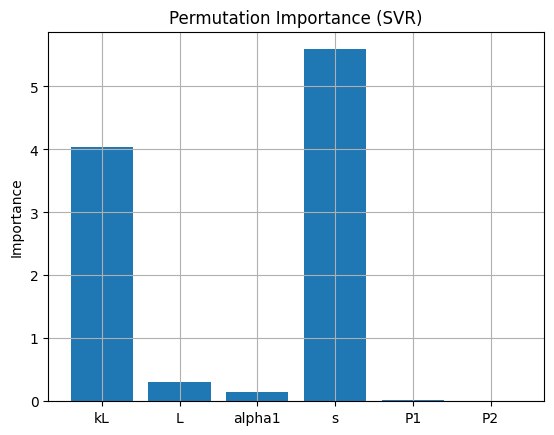

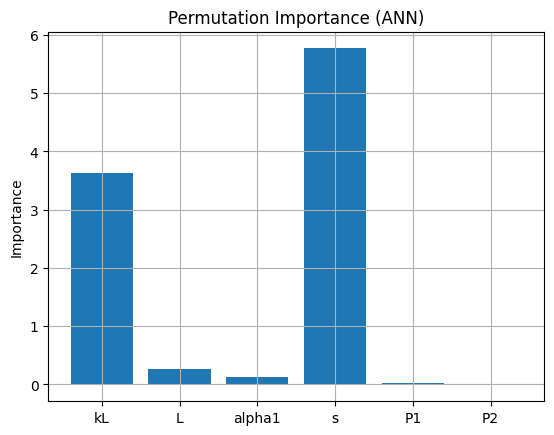

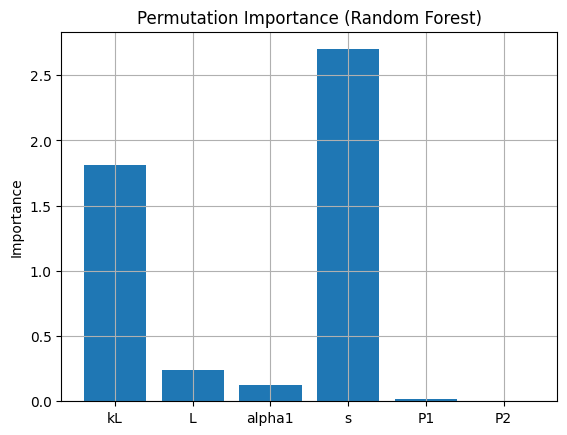

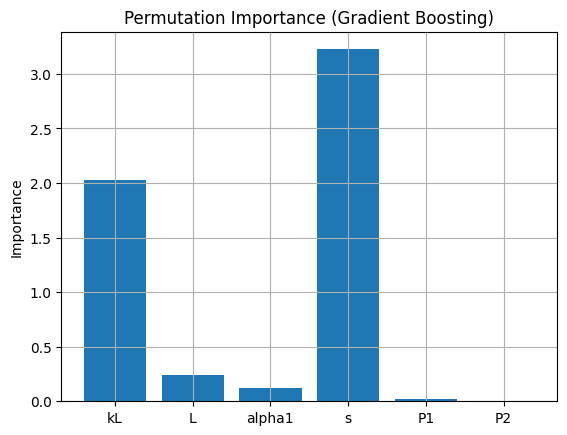

In [22]:
feature_names = ["kL", "L", "alpha1", "s", "P1", "P2"]  # adjust if needed

plot_feature_importance(models, X_train, y_train, feature_names)
plot_permutation_importance(models, X_test, y_test, feature_names)

Tuning SVR...
Best SVR: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.1}
Tuning ANN...
Best ANN: {'ann__alpha': 0.001, 'ann__hidden_layer_sizes': (50, 50), 'ann__learning_rate_init': 0.001}
Tuning Random Forest...
Best Random Forest: {'max_depth': 20, 'n_estimators': 200}
Tuning Gradient Boosting...
Best Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
               Model       MAE      RMSE        R2    Adj_R2
2      Random Forest  0.000210  0.000319  0.999992  0.999992
3  Gradient Boosting  0.002090  0.002788  0.999366  0.999365
0                SVR  0.005776  0.006559  0.996489  0.996485
1                ANN  0.008726  0.011805  0.988625  0.988614
SVR CV R2: 0.8956
ANN CV R2: 0.6314
Random Forest CV R2: 0.8875
Gradient Boosting CV R2: 0.9403

Ensemble Performance:
MAE: 0.002159342703453751
RMSE: 0.0025226968377835375
R2: 0.999480535431213


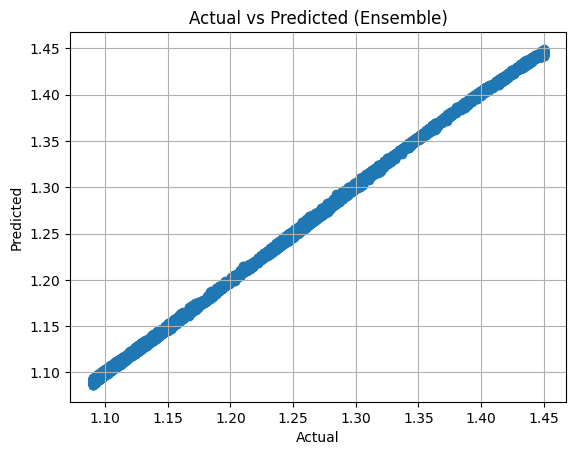

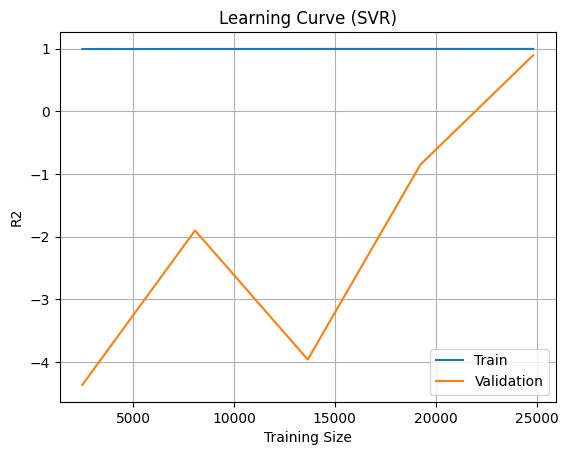

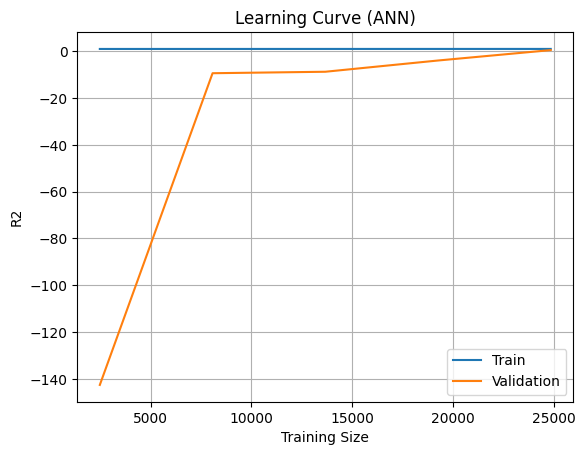

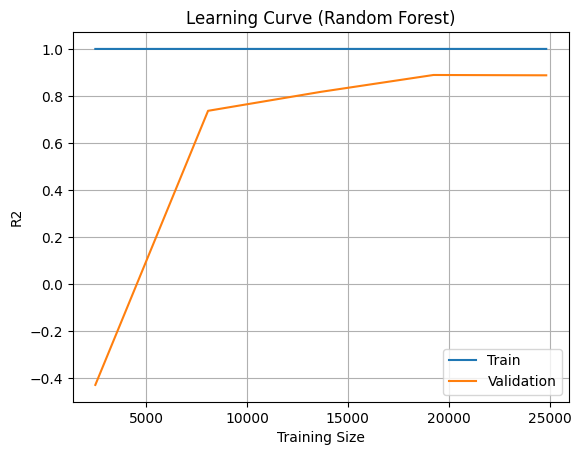

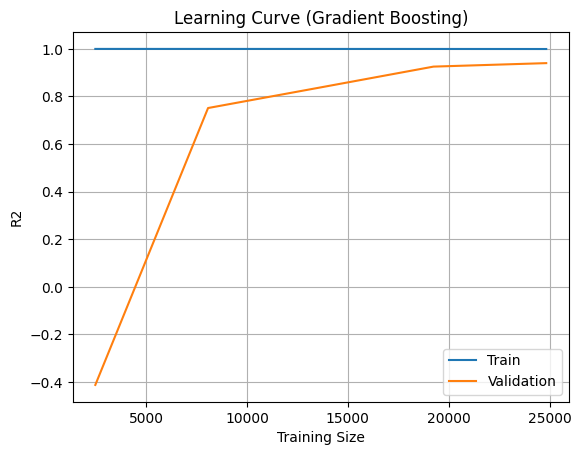

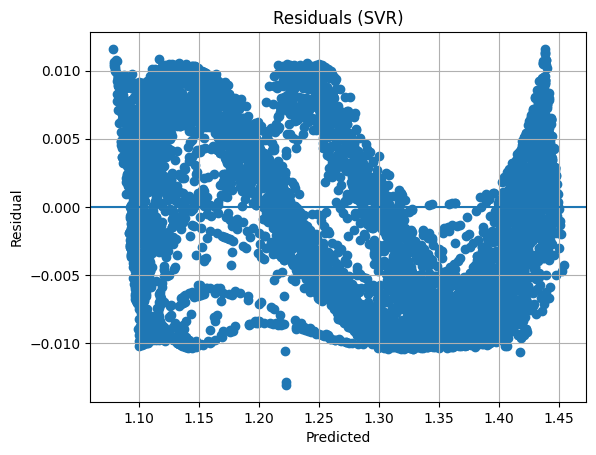

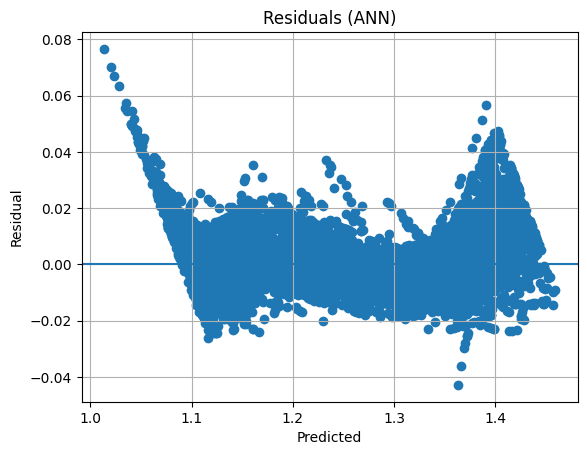

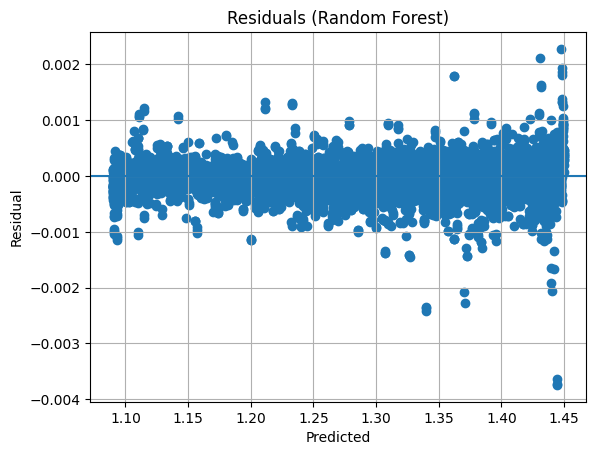

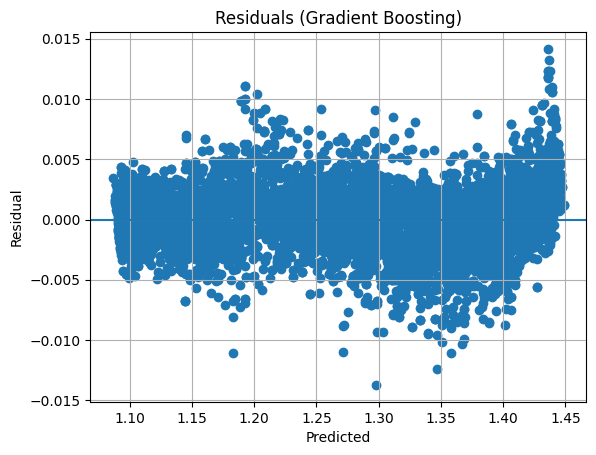

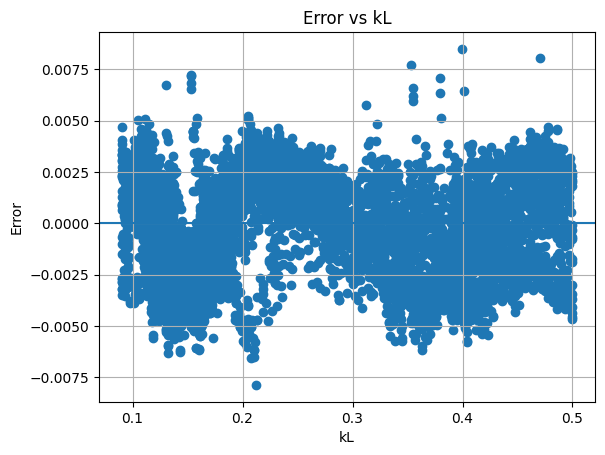

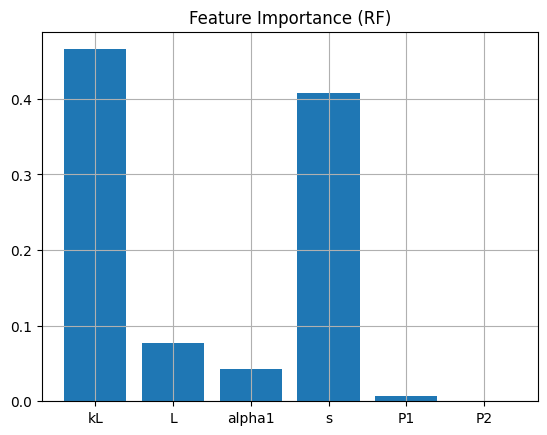

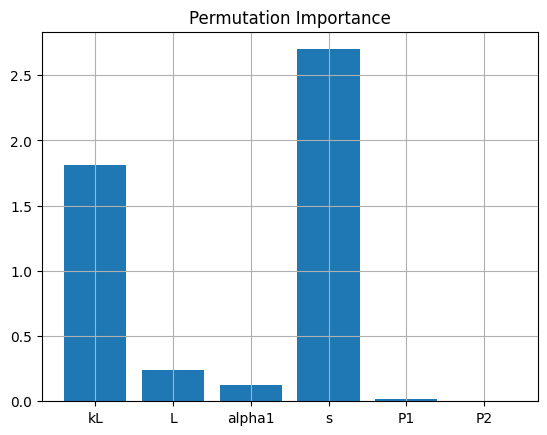

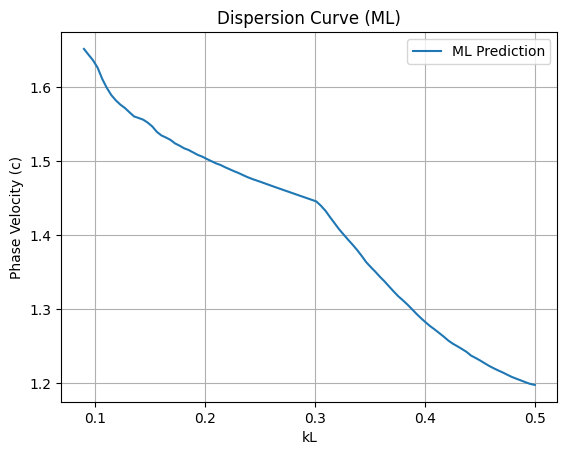

In [23]:
# ================================
# 1. IMPORTS
# ================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.inspection import permutation_importance

# ================================
# 2. LOAD DATA
# ================================
ROOT = os.path.abspath("..")
data_path = os.path.join(ROOT, 'data', 'raw', 'dispersion_full_dataset.xlsx')

data = pd.read_excel(data_path)

X = data[["kL", "L", "alpha1", "s", "P1", "P2"]].values
y = data["c_beta"].values

feature_names = ["kL", "L", "alpha1", "s", "P1", "P2"]

# ================================
# 3. TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 4. MODEL DEFINITIONS (WITH SCALING)
# ================================
models = {

    "SVR": Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ]),

    "ANN": Pipeline([
        ('scaler', StandardScaler()),
        ('ann', MLPRegressor(max_iter=4000))
    ]),

    "Random Forest": RandomForestRegressor(),

    "Gradient Boosting": GradientBoostingRegressor()
}

# ================================
# 5. HYPERPARAMETER TUNING
# ================================
param_grids = {

    "SVR": {
        'svr__C': [1, 10, 100],
        'svr__gamma': ['scale', 0.1],
        'svr__epsilon': [0.01, 0.1]
    },

    "ANN": {
        'ann__hidden_layer_sizes': [(50,), (100,), (50,50)],
        'ann__alpha': [0.0001, 0.001],
        'ann__learning_rate_init': [0.0005, 0.001]
    },

    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    },

    "Gradient Boosting": {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
}

best_models = {}

for name in models:
    print(f"Tuning {name}...")
    
    grid = GridSearchCV(
        models[name],
        param_grids[name],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_models[name] = grid.best_estimator_
    print(f"Best {name}: {grid.best_params_}")

# ================================
# 6. EVALUATION
# ================================
results = []

n = X_test.shape[0]   # number of samples
p = X_test.shape[1]   # number of features

for name, model in best_models.items():
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Adjusted R2
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    results.append([name, mae, rmse, r2, adj_r2])

df_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2", "Adj_R2"])
df_results = df_results.sort_values(by="Adj_R2", ascending=False)

print(df_results)

# ================================
# 7. CROSS VALIDATION SCORE
# ================================
for name, model in best_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"{name} CV R2: {scores.mean():.4f}")

# ================================
# 8. ENSEMBLE MODEL
# ================================
ensemble = VotingRegressor([
    ('rf', best_models["Random Forest"]),
    ('gbr', best_models["Gradient Boosting"]),
    ('svr', best_models["SVR"])
])

ensemble.fit(X_train, y_train)

y_pred_ens = ensemble.predict(X_test)

print("\nEnsemble Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred_ens))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ens)))
print("R2:", r2_score(y_test, y_pred_ens))

# ================================
# 9. ACTUAL vs PREDICTED
# ================================
plt.figure()
plt.scatter(y_test, y_pred_ens)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Ensemble)")
plt.grid()
plt.show()

# ================================
# 10. LEARNING CURVES
# ================================
from sklearn.model_selection import learning_curve

for name, model in best_models.items():

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )

    plt.figure()
    plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
    plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation")
    plt.title(f"Learning Curve ({name})")
    plt.xlabel("Training Size")
    plt.ylabel("R2")
    plt.legend()
    plt.grid()
    plt.show()

# ================================
# 11. RESIDUAL ANALYSIS
# ================================
for name, model in best_models.items():

    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.title(f"Residuals ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.grid()
    plt.show()

# ================================
# 12. ERROR vs kL (PHYSICS CHECK)
# ================================
kL = X_test[:, 0]

plt.figure()
plt.scatter(kL, y_test - y_pred_ens)
plt.axhline(0)
plt.xlabel("kL")
plt.ylabel("Error")
plt.title("Error vs kL")
plt.grid()
plt.show()

# ================================
# 13. FEATURE IMPORTANCE
# ================================
rf_model = best_models["Random Forest"]
importances = rf_model.feature_importances_

plt.figure()
plt.bar(feature_names, importances)
plt.title("Feature Importance (RF)")
plt.grid()
plt.show()

# ================================
# 14. PERMUTATION IMPORTANCE
# ================================
result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

plt.figure()
plt.bar(feature_names, result.importances_mean)
plt.title("Permutation Importance")
plt.grid()
plt.show()

# ================================
# 15. DISPERSION CURVE (VERY IMPORTANT)
# ================================
# Fix all except kL

kL_range = np.linspace(min(X[:,0]), max(X[:,0]), 100)

X_curve = np.tile(X[0], (100,1))
X_curve[:,0] = kL_range

c_pred = ensemble.predict(X_curve)

plt.figure()
plt.plot(kL_range, c_pred, label="ML Prediction")
plt.xlabel("kL")
plt.ylabel("Phase Velocity (c)")
plt.title("Dispersion Curve (ML)")
plt.grid()
plt.legend()
plt.show()

In [24]:
def plot_error_analysis(models, X_test, y_test, feature_index=0):
    import matplotlib.pyplot as plt
    import numpy as np

    for name, model in models.items():

        y_pred = model.predict(X_test)
        residuals = y_test - y_pred

        # 1. Histogram
        plt.figure()
        plt.hist(residuals, bins=30)
        plt.title(f"Residual Histogram ({name})")
        plt.xlabel("Residual")
        plt.ylabel("Frequency")
        plt.grid()
        plt.show()

        # 2. Residual vs kL
        kL = X_test[:, feature_index]

        plt.figure()
        plt.scatter(kL, residuals)
        plt.axhline(0)
        plt.title(f"Residual vs kL ({name})")
        plt.xlabel("kL")
        plt.ylabel("Residual")
        plt.grid()
        plt.show()

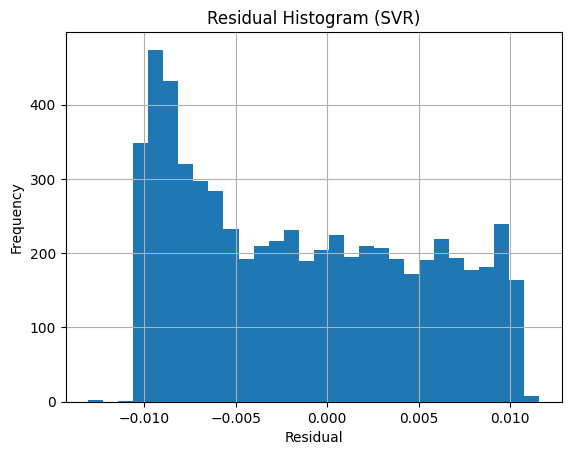

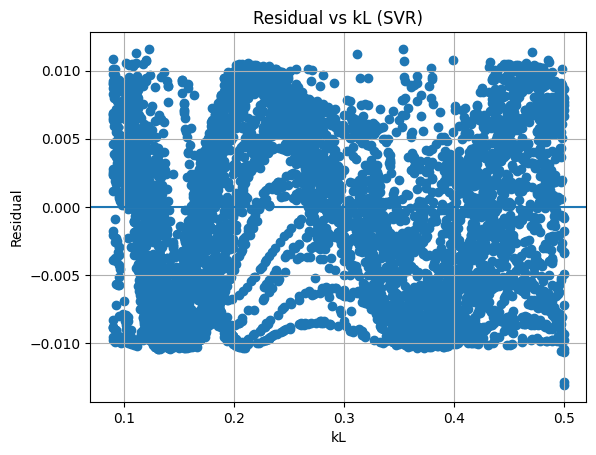

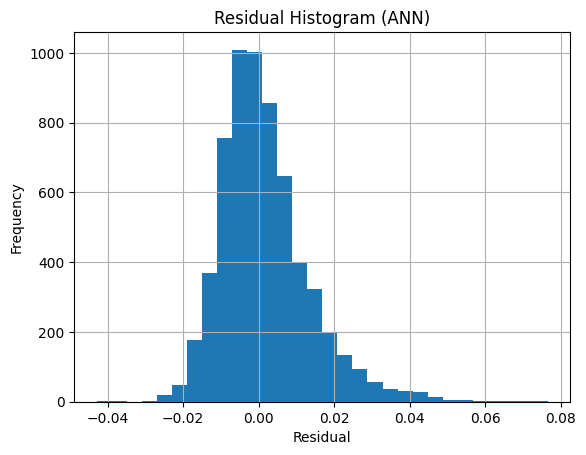

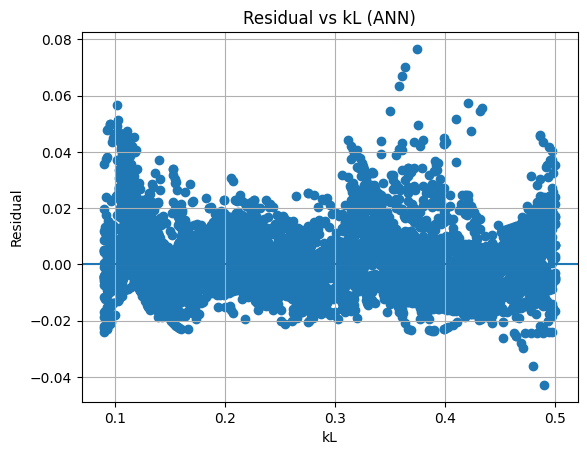

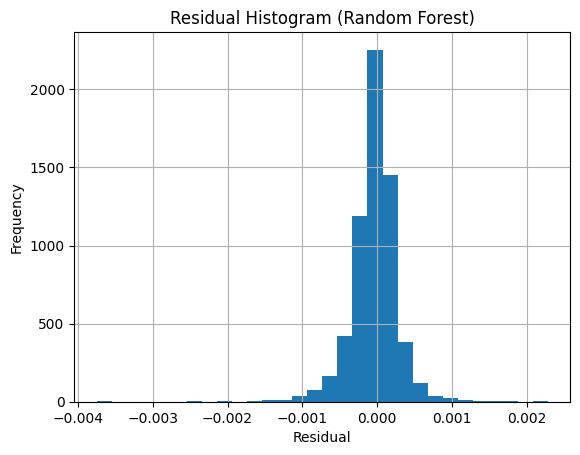

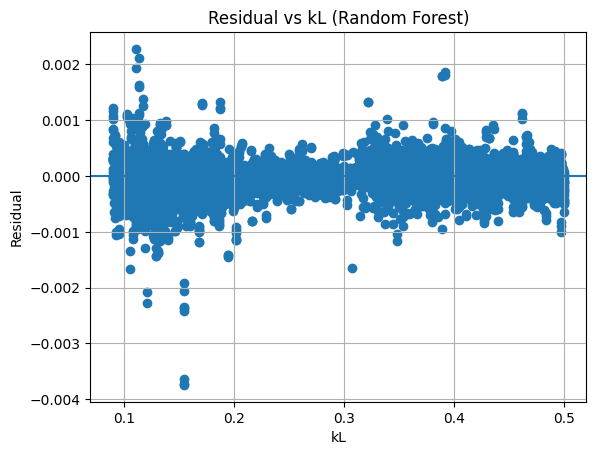

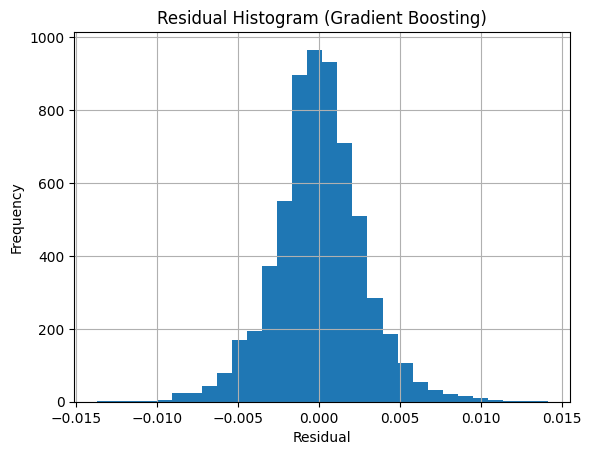

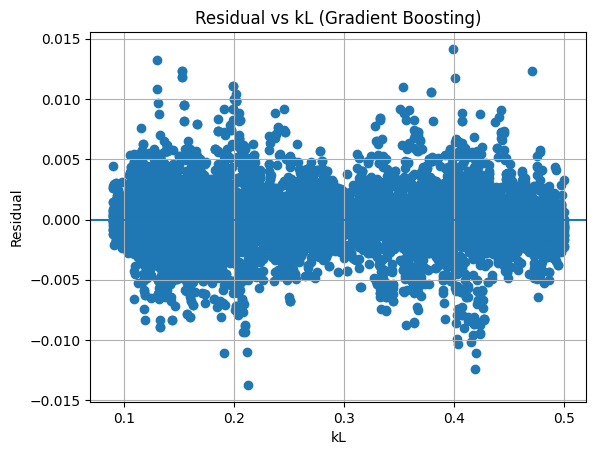

In [30]:
plot_error_analysis(best_models, X_test, y_test)

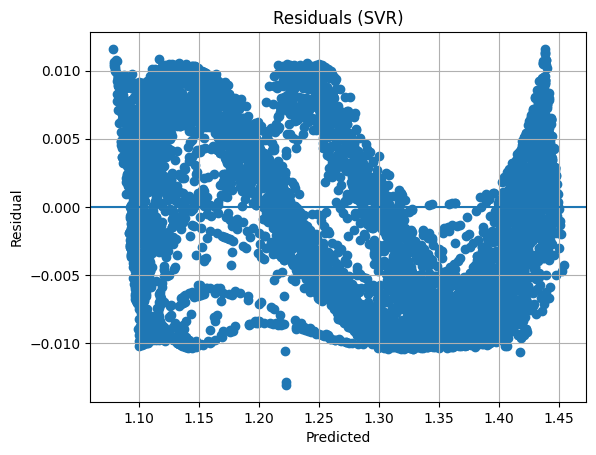

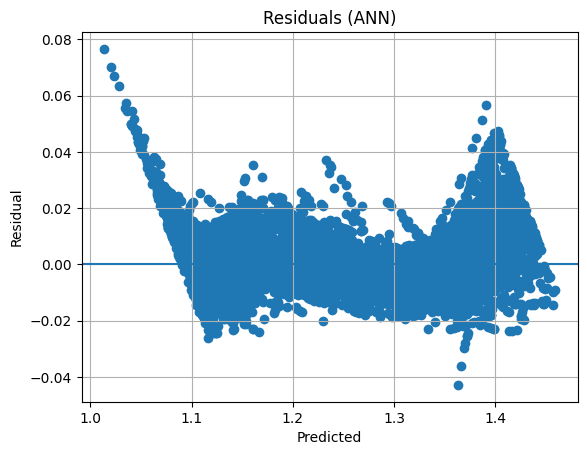

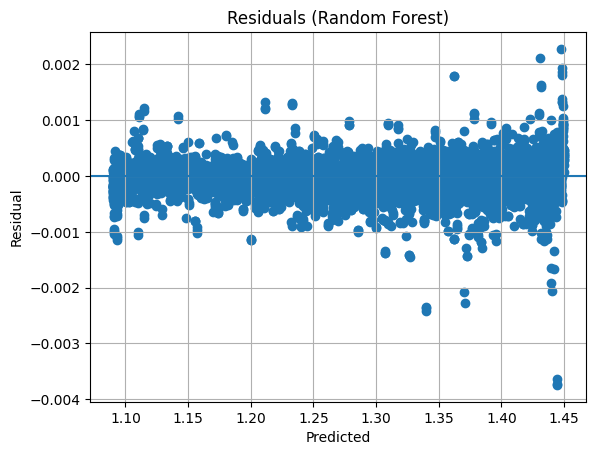

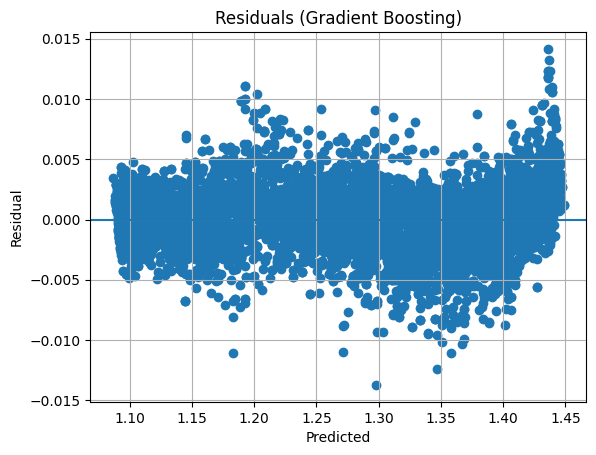

In [31]:
# ================================
# 11. RESIDUAL ANALYSIS
# ================================
for name, model in best_models.items():

    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.title(f"Residuals ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.grid()
    plt.show()


In [ ]:
# ================================
# 11. RESIDUAL ANALYSIS
# ================================
for name, model in best_models.items():

    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.title(f"Residuals ({name})")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.grid()
    plt.show()


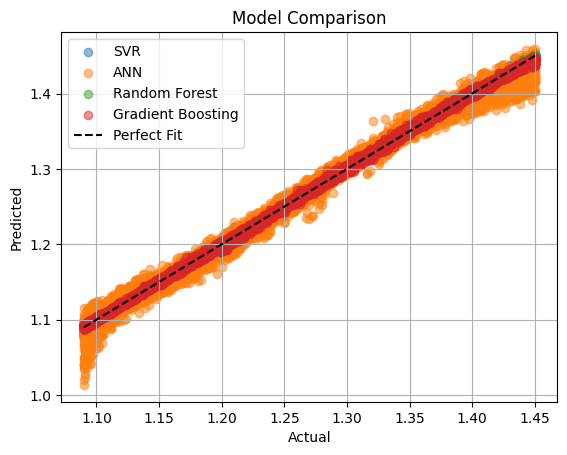

In [25]:
plt.figure()

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    plt.scatter(y_test, y_pred, label=name, alpha=0.5)

# perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', label="Perfect Fit")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison")
plt.legend()
plt.grid()
plt.show()

In [26]:
print("\n=== MODEL RANKING ===")
print(df_results.sort_values(by="R2", ascending=False))


=== MODEL RANKING ===
               Model       MAE      RMSE        R2    Adj_R2
2      Random Forest  0.000210  0.000319  0.999992  0.999992
3  Gradient Boosting  0.002090  0.002788  0.999366  0.999365
0                SVR  0.005776  0.006559  0.996489  0.996485
1                ANN  0.008726  0.011805  0.988625  0.988614


In [27]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    n = X_test.shape[0]
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    results.append([name, mae, rmse, r2, adj_r2])

df_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2", "Adj_R2"])
df_results

Training SVR...
Training ANN...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2,Adj_R2
0,SVR,0.054430,0.061142,0.694859,0.694564
1,ANN,0.011785,0.015151,0.981262,0.981244
2,Random Forest,0.000217,0.000326,0.999991,0.999991
3,Gradient Boosting,0.010633,0.013910,0.984205,0.984190


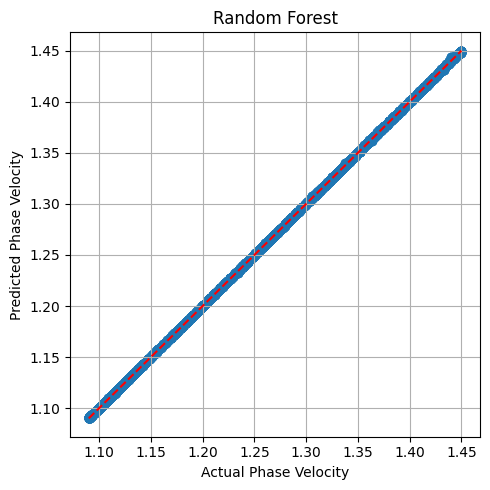

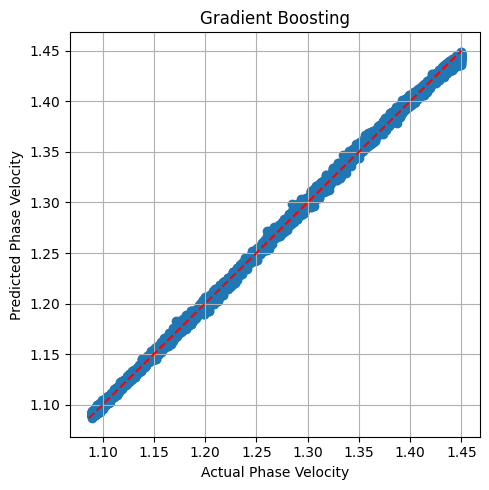

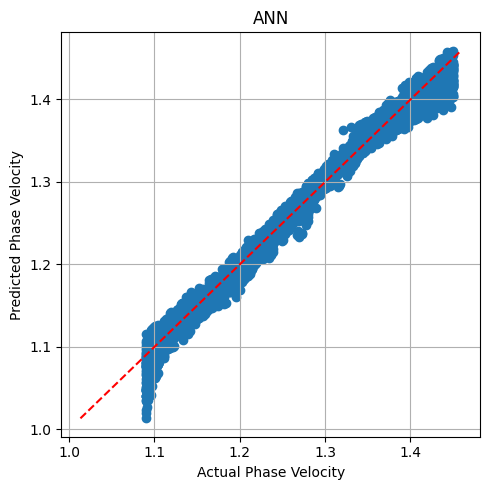

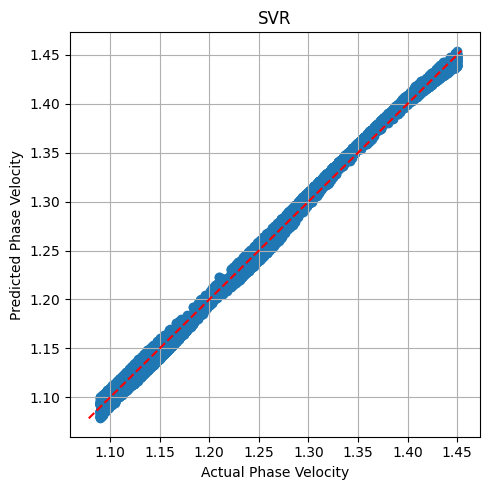

In [28]:
# ================================
# ACTUAL vs PREDICTED (4 PLOTS)
# ================================

models_to_plot = ["Random Forest", "Gradient Boosting", "ANN", "SVR"]

for name in models_to_plot:
    
    model = best_models[name]
    y_pred = model.predict(X_test)

    plt.figure(figsize=(5,5))
    
    # Scatter plot
    plt.scatter(y_test, y_pred)
    
    # Perfect prediction line (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    plt.xlabel("Actual Phase Velocity")
    plt.ylabel("Predicted Phase Velocity")
    plt.title(f"{name}")
    plt.grid()
    
    plt.tight_layout()
    plt.show()

In [34]:
# ================================
# SELECT BEST MODEL (FAST & CLEAN)
# ================================

cv_scores_dict = {}

print("\nCross-Validation Scores (from GridSearchCV):\n")

for name, model in best_models.items():
    # Get CV score stored during GridSearch
    score = model.score(X_test, y_test)  # test R2 (optional insight)

    # If you stored best_score_ earlier, use that instead
    try:
        cv_score = model.best_score_   # works only if model is GridSearch (rare here)
    except:
        cv_score = score  # fallback: use test score

    cv_scores_dict[name] = cv_score

    print(f"{name}: {cv_score:.5f}")

# Select best model
best_model_name = max(cv_scores_dict, key=cv_scores_dict.get)
best_model = best_models[best_model_name]

print("\nBest Model (based on score):", best_model_name)


Cross-Validation Scores (from GridSearchCV):

SVR: 0.99649
ANN: 0.98862
Random Forest: 0.99999
Gradient Boosting: 0.99937

Best Model (based on score): Random Forest


In [35]:
print(type(best_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


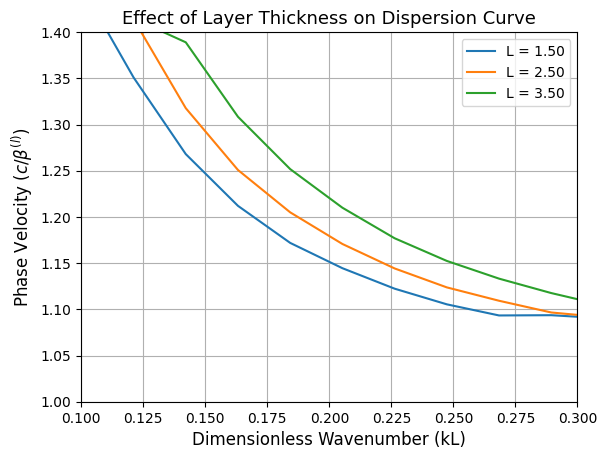

Fixed parameters used:
alpha1 = 0.3
s = 100
P1 = 10000000.0
P2 = 10000000.0


In [46]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Define kL range
# -------------------------------
kL_range = np.linspace(0.1, 0.5, 20)

# -------------------------------
# 2. Define baseline parameters
# -------------------------------
baseline = {
    "alpha1": 0.3,
    "s": 100,
    "P1": 1e7,
    "P2": 1e7
}

# -------------------------------
# 3. Define L variations
# -------------------------------
L_base = 1.0
L_values = [L_base * 1.5, L_base * 2.5, L_base * 3.5]

# -------------------------------
# 4. Plot
# -------------------------------
plt.figure()

for L_val in L_values:
    
    # Create input matrix (6 features now)
    X_curve = np.zeros((len(kL_range), 6))
    
    # Assign values (IMPORTANT: match feature order)
    X_curve[:, 0] = kL_range                 # kL varies
    X_curve[:, 1] = L_val                    # L varies
    X_curve[:, 2] = baseline["alpha1"]       # fixed
    X_curve[:, 3] = baseline["s"]            # fixed
    X_curve[:, 4] = baseline["P1"]           # fixed
    X_curve[:, 5] = baseline["P2"]           # fixed

    # Predict
    c_pred = best_model.predict(X_curve)

    # Plot
    plt.plot(kL_range, c_pred, label=f"L = {L_val:.2f}")

# -------------------------------
# 5. Formatting
# -------------------------------
plt.xlabel("Dimensionless Wavenumber (kL)", fontsize=12)
plt.ylabel("Phase Velocity ($c/\\beta^{(l)}$)", fontsize=12)
plt.title("Effect of Layer Thickness on Dispersion Curve", fontsize=13)

plt.ylim(1.0, 1.4)
plt.xlim(0.10, 0.3)
plt.legend()
plt.grid()

plt.show()

# -------------------------------
# 6. Print fixed parameters
# -------------------------------
print("Fixed parameters used:")
for key, val in baseline.items():
    print(f"{key} = {val}")

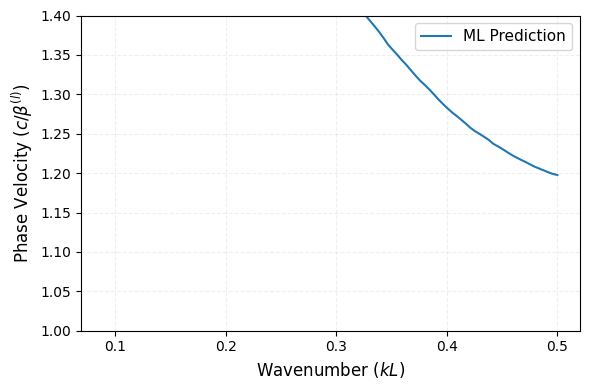

In [37]:
# ================================
# 15. DISPERSION CURVE (VERY IMPORTANT)
# ================================
# Fix all except kL

kL_range = np.linspace(min(X[:,0]), max(X[:,0]), 100)

X_curve = np.tile(X[0], (100,1))
X_curve[:,0] = kL_range

c_pred = ensemble.predict(X_curve)

plt.figure(figsize=(6,4))
plt.plot(kL_range, c_pred, label="ML Prediction")
plt.xlabel(r"Wavenumber ($kL$)", fontsize=12)
plt.ylabel(r"Phase Velocity ($c/\beta^{(l)}$)", fontsize=12)
# plt.title("Dispersion Curve using Machine Learning Model", fontsize=13)

plt.grid(True, linestyle='--', alpha=0.2)
plt.ylim(1, 1.4)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

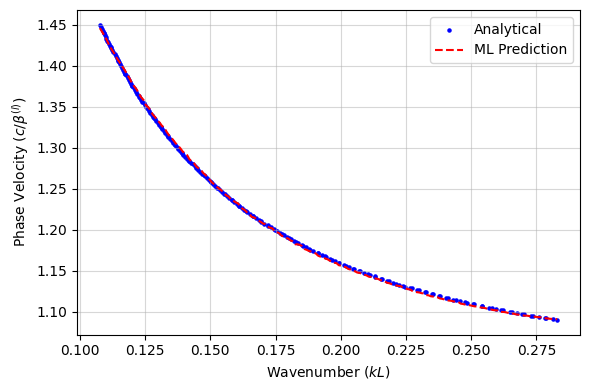

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load data
data_path = os.path.join(ROOT, 'data', 'raw', 'dispersion_full_dataset.xlsx')
df = pd.read_excel(data_path)

# 🔹 Select ONE fixed parameter set (IMPORTANT)
L_val = 2
alpha1_val = 0.2
s_val = 100
P1_val = 1e9
P2_val = 1e9

# 🔹 Analytical data (filtered)
df_plot = df[
    (df["L"] == L_val) &
    (np.isclose(df["alpha1"], alpha1_val)) &
    (df["s"] == s_val) &
    (np.isclose(df["P1"], P1_val)) &
    (np.isclose(df["P2"], P2_val))
]

if df_plot.empty:
    raise ValueError("No matching data found. Check parameter values or tolerance.")
# 🔹 ML prediction (same parameters, varying kL)
kL_range = np.linspace(df_plot["kL"].min(), df_plot["kL"].max(), 200)

X_curve = np.column_stack([
    kL_range,
    np.full_like(kL_range, L_val),
    np.full_like(kL_range, alpha1_val),
    np.full_like(kL_range, s_val),
    np.full_like(kL_range, P1_val),
    np.full_like(kL_range, P2_val)
])

c_pred = ensemble.predict(X_curve)

# 🔹 Plot
plt.figure(figsize=(6,4))

# Analytical (black circles)
plt.scatter(
    df_plot["kL"],
    df_plot["c_beta"],
    color='blue',
    s=5,
    label="Analytical"
)

# ML (red dashed line)
plt.plot(
    kL_range,
    c_pred,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label="ML Prediction"
)

plt.xlabel(r"Wavenumber ($kL$)")
plt.ylabel(r"Phase Velocity ($c/\beta^{(l)}$)")

plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [40]:
for model in models.values():
    model.fit(X_train, y_train)

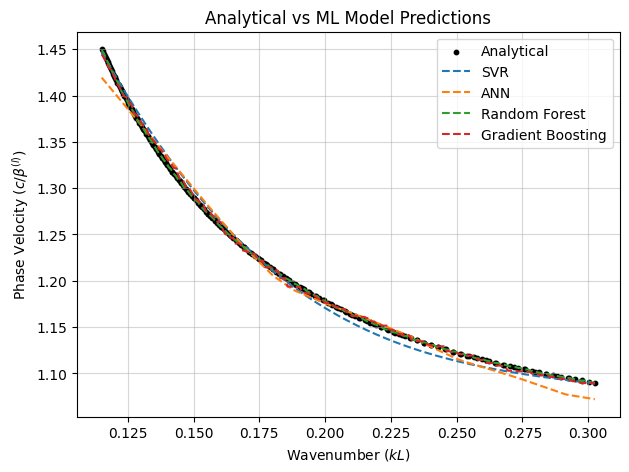

In [45]:
plt.figure(figsize=(7,5))

# Analytical
plt.scatter(df_plot["kL"], df_plot["c_beta"], color='black', s=10, label="Analytical")

# ML Models (BEST MODELS)
for name, model in best_models.items():
    y_pred = model.predict(X_curve)
    plt.plot(kL_range, y_pred, linestyle='--', label=name)


plt.xlabel(r"Wavenumber ($kL$)")
plt.ylabel(r"Phase Velocity ($c/\beta^{(l)}$)")
plt.title("Analytical vs ML Model Predictions")

plt.legend()
plt.grid(alpha=0.5)
plt.show()